# Advanced Feature Selection and Feature Engineering for Wine Classification

Feature selection and feature engineering are important techniques used to improve machine learning models by identifying the most relevant variables and creating more informative features. These methods help increase model accuracy, reduce overfitting, and simplify model interpretation.

In this project, several feature selection techniques such as Variance Threshold, Mutual Information (SelectKBest), Recursive Feature Elimination (RFE), correlation filtering, and model-based importance methods are applied to the Wine Classification dataset. The goal is to evaluate and compare these approaches to determine which feature set provides the best performance for predicting wine classes.

In [1]:
# 1. Imports

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif,
    RFE
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

In [2]:
# 2. Helper functions

def correlation_filter(df_features: pd.DataFrame, threshold: float = 0.85) -> list:
    """Return highly correlated features to drop."""
    corr = df_features.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return to_drop


def evaluate_feature_subset(
    model,
    X_train_df: pd.DataFrame,
    y_train: pd.Series,
    X_valid_df: pd.DataFrame,
    y_valid: pd.Series
) -> float:
    """Train model on selected features and return weighted F1."""
    model.fit(X_train_df, y_train)
    preds = model.predict(X_valid_df)
    return f1_score(y_valid, preds, average="weighted")


def summarize_eval(eval_rows: list[dict]) -> pd.DataFrame:
    """Create sorted comparison dataframe."""
    out = pd.DataFrame(eval_rows).sort_values("weighted_f1", ascending=False).reset_index(drop=True)
    out.index = out.index + 1
    return out

In [3]:
# 3. Load data

wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

print("Dataset shape:", df.shape)
print("\nPreview:")
print(df.head())

print("\nTarget distribution:")
print(df["target"].value_counts().sort_index())

Dataset shape: (178, 14)

Preview:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_w

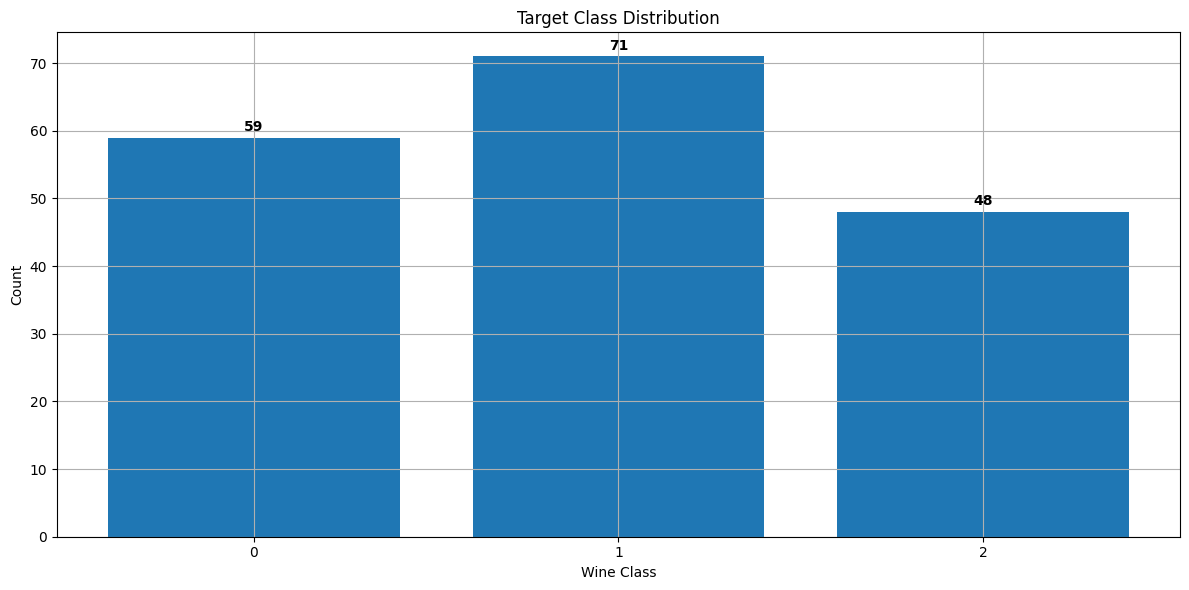

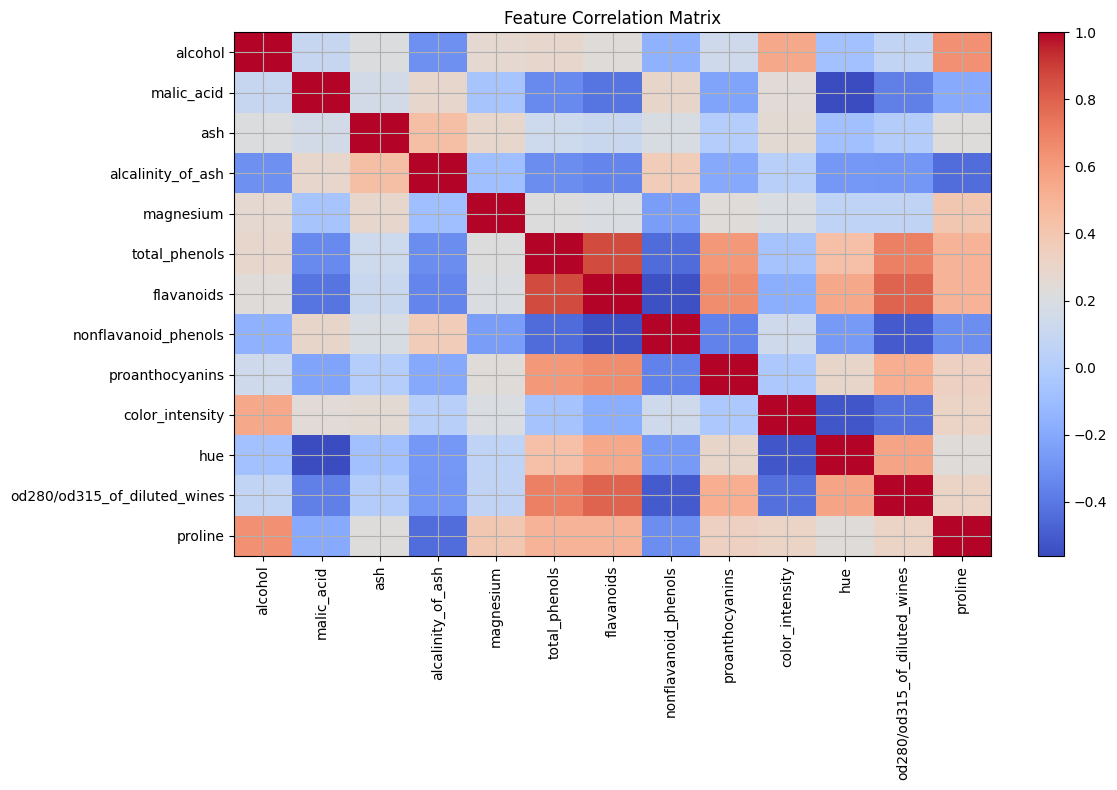

In [4]:
# 4. Basic EDA

fig, ax = plt.subplots()
class_counts = df["target"].value_counts().sort_index()
ax.bar(class_counts.index.astype(str), class_counts.values)
ax.set_xlabel("Wine Class")
ax.set_ylabel("Count")
ax.set_title("Target Class Distribution")

for i, v in enumerate(class_counts.values):
    ax.text(i, v + 1, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

# Correlation heatmap
corr_matrix = df.drop(columns=["target"]).corr()
plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [5]:
# 5. Train / validation / test split

X = df.drop(columns=["target"])
y = df["target"]

# 60/20/20 split
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_temp,
    y_train_temp,
    test_size=0.25,   # 0.25 of 0.80 => 0.20 overall
    stratify=y_train_temp,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_valid.shape)
print("Test shape:", X_test.shape)

Train shape: (106, 13)
Validation shape: (36, 13)
Test shape: (36, 13)



Baseline weighted F1 (validation): 0.9721

Baseline classification report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



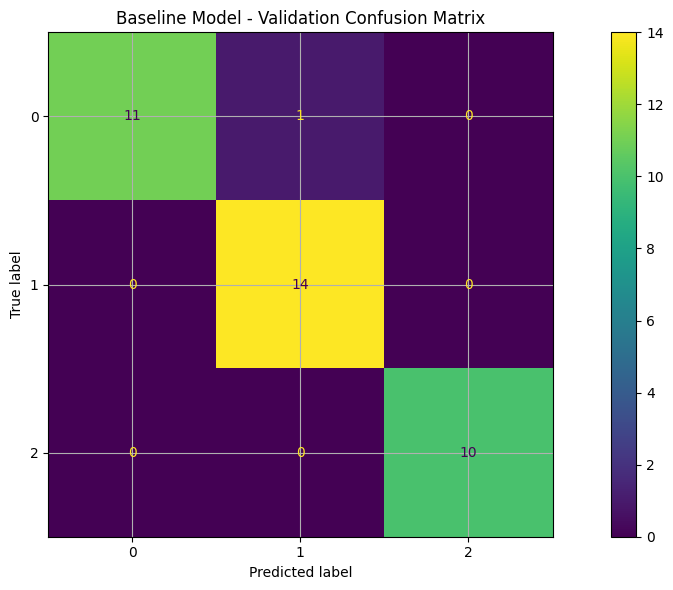

In [6]:
# 6. Baseline model with all original features

baseline_model = GradientBoostingClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

baseline_valid_preds = baseline_model.predict(X_valid)
baseline_f1 = f1_score(y_valid, baseline_valid_preds, average="weighted")

print("\nBaseline weighted F1 (validation):", round(baseline_f1, 4))
print("\nBaseline classification report:")
print(classification_report(y_valid, baseline_valid_preds))

ConfusionMatrixDisplay.from_predictions(y_valid, baseline_valid_preds)
plt.title("Baseline Model - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [7]:
# 7. Correlation filtering

corr_drop_features = correlation_filter(X_train, threshold=0.85)
corr_filtered_features = [col for col in X_train.columns if col not in corr_drop_features]

print("\nHighly correlated features suggested for removal:")
print(corr_drop_features)

print("\nCorrelation-filtered feature set:")
print(corr_filtered_features)


Highly correlated features suggested for removal:
['flavanoids']

Correlation-filtered feature set:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [8]:
# 8. Variance Threshold

# Scale to compare variances fairly
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)

var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X_train_mm)

var_mask = var_selector.get_support()
var_selected_features = X_train.columns[var_mask].tolist()

print("\nVariance Threshold selected features:")
print(var_selected_features)

var_model = GradientBoostingClassifier(random_state=42)
f1_var = evaluate_feature_subset(
    var_model,
    X_train[var_selected_features],
    y_train,
    X_valid[var_selected_features],
    y_valid
)

print("Variance Threshold weighted F1:", round(f1_var, 4))


Variance Threshold selected features:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Variance Threshold weighted F1: 0.9721



Mutual Information scores:
                         feature  mi_score
0                     flavanoids  0.680801
1                color_intensity  0.540651
2                  total_phenols  0.521112
3                        proline  0.487806
4                        alcohol  0.435934
5                            hue  0.432827
6   od280/od315_of_diluted_wines  0.432306
7                proanthocyanins  0.318077
8                     malic_acid  0.297309
9              alcalinity_of_ash  0.269507
10                     magnesium  0.211150
11          nonflavanoid_phenols  0.093445
12                           ash  0.031307


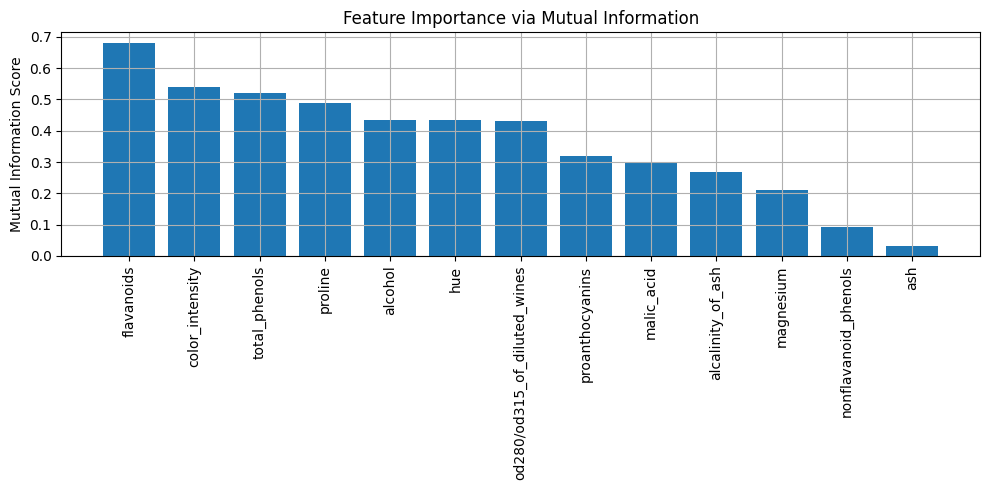


SelectKBest search results:
     k  weighted_f1
0    1     0.752031
1    2     0.972263
2    3     0.945336
3    4     0.942393
4    5     0.972047
5    6     0.942393
6    7     0.917602
7    8     0.917602
8    9     0.944192
9   10     0.972097
10  11     1.000000
11  12     1.000000
12  13     0.972097


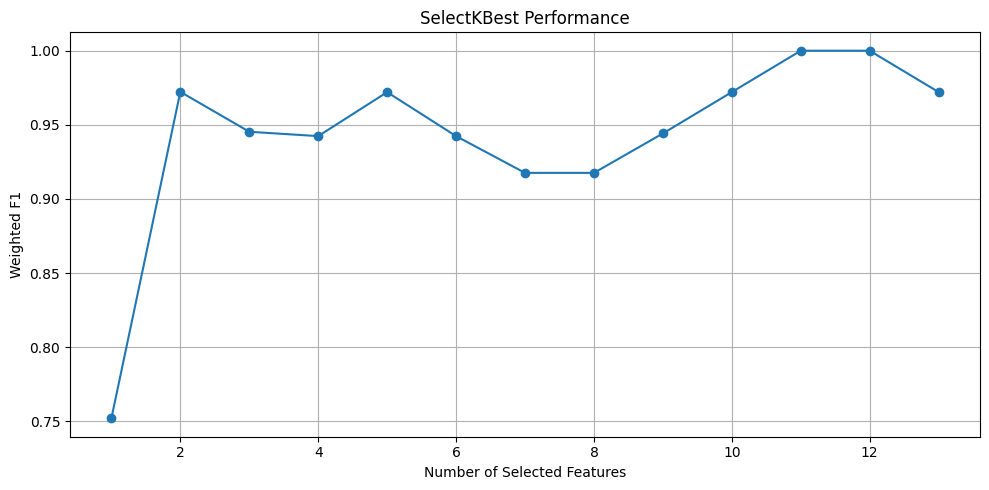


Best k for SelectKBest: 11
Best SelectKBest features:
['alcohol', 'malic_acid', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [9]:
# 9. Mutual Information + SelectKBest

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_df = pd.DataFrame({
    "feature": X_train.columns,
    "mi_score": mi_scores
}).sort_values("mi_score", ascending=False).reset_index(drop=True)

print("\nMutual Information scores:")
print(mi_df)

plt.figure(figsize=(10, 5))
plt.bar(mi_df["feature"], mi_df["mi_score"])
plt.xticks(rotation=90)
plt.ylabel("Mutual Information Score")
plt.title("Feature Importance via Mutual Information")
plt.tight_layout()
plt.show()

kbest_results = []

for k in range(1, X_train.shape[1] + 1):
    selector = SelectKBest(score_func=mutual_info_classif, k=k)
    selector.fit(X_train, y_train)

    selected_cols = X_train.columns[selector.get_support()].tolist()

    model = GradientBoostingClassifier(random_state=42)
    score = evaluate_feature_subset(
        model,
        X_train[selected_cols],
        y_train,
        X_valid[selected_cols],
        y_valid
    )

    kbest_results.append({
        "k": k,
        "weighted_f1": score
    })

kbest_df = pd.DataFrame(kbest_results)
best_k = int(kbest_df.loc[kbest_df["weighted_f1"].idxmax(), "k"])

print("\nSelectKBest search results:")
print(kbest_df)

plt.figure(figsize=(10, 5))
plt.plot(kbest_df["k"], kbest_df["weighted_f1"], marker="o")
plt.xlabel("Number of Selected Features")
plt.ylabel("Weighted F1")
plt.title("SelectKBest Performance")
plt.tight_layout()
plt.show()

best_k_selector = SelectKBest(score_func=mutual_info_classif, k=best_k)
best_k_selector.fit(X_train, y_train)
kbest_features = X_train.columns[best_k_selector.get_support()].tolist()

print("\nBest k for SelectKBest:", best_k)
print("Best SelectKBest features:")
print(kbest_features)


RFE search results:
     k  weighted_f1
0    1     0.752031
1    2     0.972263
2    3     0.944961
3    4     0.971970
4    5     0.943210
5    6     0.944444
6    7     0.917602
7    8     0.944192
8    9     0.911721
9   10     0.911721
10  11     1.000000
11  12     1.000000
12  13     0.972097


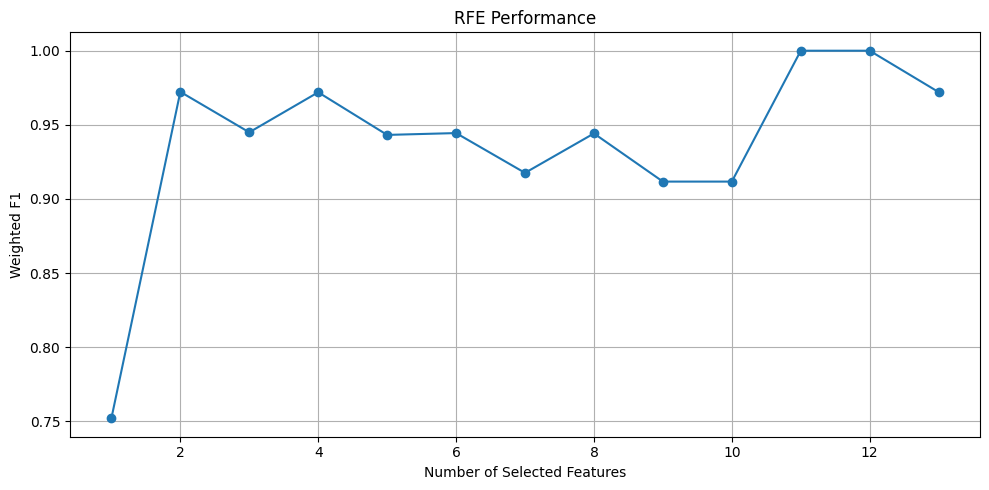


Best k for RFE: 11
Best RFE features:
['alcohol', 'malic_acid', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [10]:
# 10. Recursive Feature Elimination (RFE)

rfe_results = []

for k in range(1, X_train.shape[1] + 1):
    rfe_selector = RFE(
        estimator=RandomForestClassifier(n_estimators=200, random_state=42),
        n_features_to_select=k,
        step=1
    )
    rfe_selector.fit(X_train, y_train)

    selected_cols = X_train.columns[rfe_selector.get_support()].tolist()

    model = GradientBoostingClassifier(random_state=42)
    score = evaluate_feature_subset(
        model,
        X_train[selected_cols],
        y_train,
        X_valid[selected_cols],
        y_valid
    )

    rfe_results.append({
        "k": k,
        "weighted_f1": score
    })

rfe_df = pd.DataFrame(rfe_results)
best_rfe_k = int(rfe_df.loc[rfe_df["weighted_f1"].idxmax(), "k"])

print("\nRFE search results:")
print(rfe_df)

plt.figure(figsize=(10, 5))
plt.plot(rfe_df["k"], rfe_df["weighted_f1"], marker="o")
plt.xlabel("Number of Selected Features")
plt.ylabel("Weighted F1")
plt.title("RFE Performance")
plt.tight_layout()
plt.show()

final_rfe_selector = RFE(
    estimator=RandomForestClassifier(n_estimators=200, random_state=42),
    n_features_to_select=best_rfe_k,
    step=1
)
final_rfe_selector.fit(X_train, y_train)
rfe_features = X_train.columns[final_rfe_selector.get_support()].tolist()

print("\nBest k for RFE:", best_rfe_k)
print("Best RFE features:")
print(rfe_features)


Random Forest feature importances:
                         feature  importance
0                color_intensity    0.171245
1                     flavanoids    0.160172
2                        alcohol    0.132757
3                        proline    0.132679
4   od280/od315_of_diluted_wines    0.096663
5                            hue    0.091818
6                  total_phenols    0.072305
7                      magnesium    0.033460
8                     malic_acid    0.031450
9              alcalinity_of_ash    0.026552
10               proanthocyanins    0.024983
11          nonflavanoid_phenols    0.014019
12                           ash    0.011898


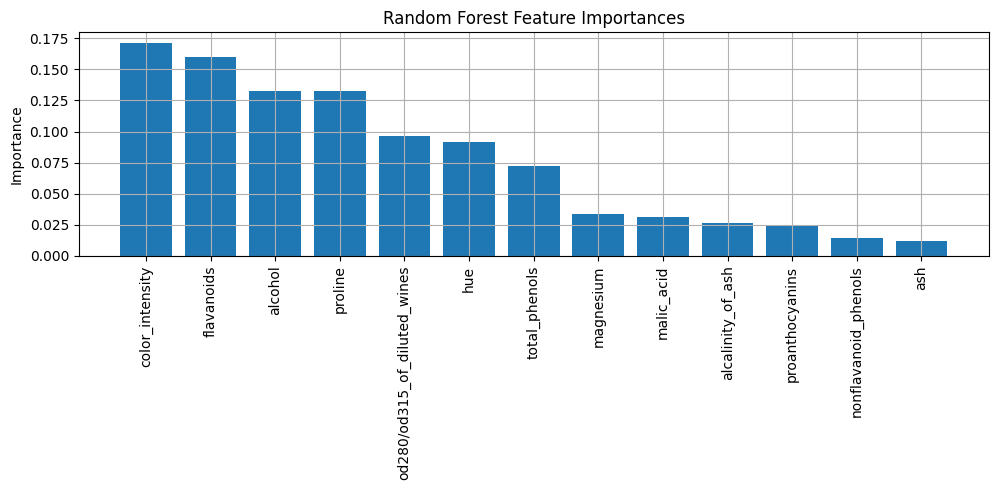


Top Random Forest features:
['color_intensity', 'flavanoids', 'alcohol', 'proline', 'od280/od315_of_diluted_wines']


In [11]:
# 11. Tree-based feature importance

rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

rf_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\nRandom Forest feature importances:")
print(rf_importance_df)

plt.figure(figsize=(10, 5))
plt.bar(rf_importance_df["feature"], rf_importance_df["importance"])
plt.xticks(rotation=90)
plt.ylabel("Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

top_rf_features = rf_importance_df.head(5)["feature"].tolist()

print("\nTop Random Forest features:")
print(top_rf_features)


Permutation importances:
                         feature  importance_mean
0                color_intensity         0.217984
1                     flavanoids         0.192418
2                        proline         0.066736
3                            ash         0.066244
4                            hue         0.056304
5                  total_phenols         0.050112
6                      magnesium         0.050102
7                proanthocyanins         0.012557
8                        alcohol         0.011024
9              alcalinity_of_ash         0.008371
10                    malic_acid         0.000000
11          nonflavanoid_phenols         0.000000
12  od280/od315_of_diluted_wines         0.000000


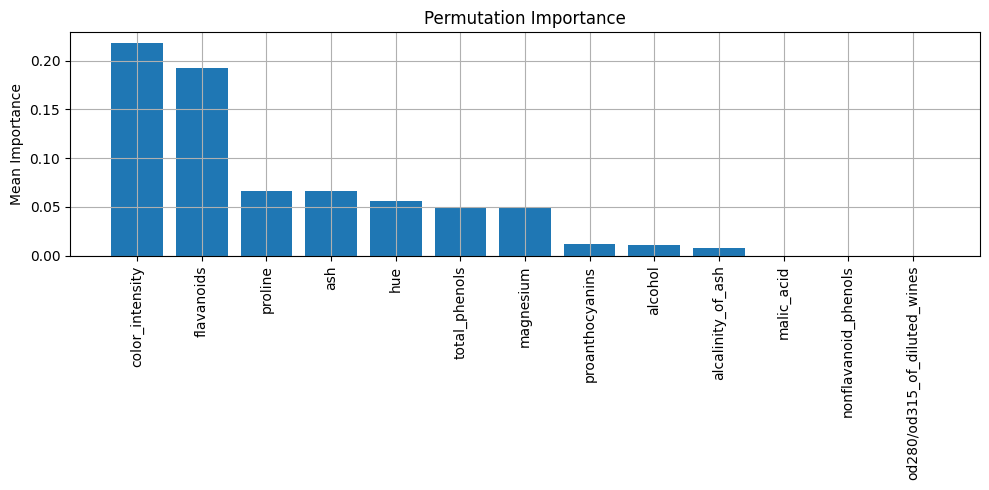


Top permutation features:
['color_intensity', 'flavanoids', 'proline', 'ash', 'hue']


In [12]:
# 12. Permutation importance

perm_model = GradientBoostingClassifier(random_state=42)
perm_model.fit(X_train, y_train)

perm = permutation_importance(
    perm_model,
    X_valid,
    y_valid,
    scoring="f1_weighted",
    n_repeats=20,
    random_state=42
)

perm_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": perm.importances_mean
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print("\nPermutation importances:")
print(perm_df)

plt.figure(figsize=(10, 5))
plt.bar(perm_df["feature"], perm_df["importance_mean"])
plt.xticks(rotation=90)
plt.ylabel("Mean Importance")
plt.title("Permutation Importance")
plt.tight_layout()
plt.show()

top_perm_features = perm_df.head(5)["feature"].tolist()

print("\nTop permutation features:")
print(top_perm_features)

In [13]:
# 13. Feature engineering

X_train_eng = X_train.copy()
X_valid_eng = X_valid.copy()
X_test_eng = X_test.copy()

for dataset in [X_train_eng, X_valid_eng, X_test_eng]:
    dataset["phenols_flavanoids_ratio"] = dataset["total_phenols"] / (dataset["flavanoids"] + 1e-6)
    dataset["alcohol_proline_interaction"] = dataset["alcohol"] * dataset["proline"]
    dataset["color_hue_interaction"] = dataset["color_intensity"] * dataset["hue"]
    dataset["malic_magnesium_ratio"] = dataset["malic_acid"] / (dataset["magnesium"] + 1e-6)

engineered_only = [col for col in X_train_eng.columns if col not in X_train.columns]

print("\nEngineered features added:")
print(engineered_only)


Engineered features added:
['phenols_flavanoids_ratio', 'alcohol_proline_interaction', 'color_hue_interaction', 'malic_magnesium_ratio']



Comparison of feature strategies:
                       method  n_features  weighted_f1
1                         RFE          11     1.000000
2                 SelectKBest          11     1.000000
3  Top Permutation Importance           5     0.972263
4          Variance Threshold          13     0.972097
5                All Features          13     0.972097
6        Correlation Filtered          12     0.944961
7     Engineered All Features          17     0.944444
8           Top RF Importance           5     0.943210


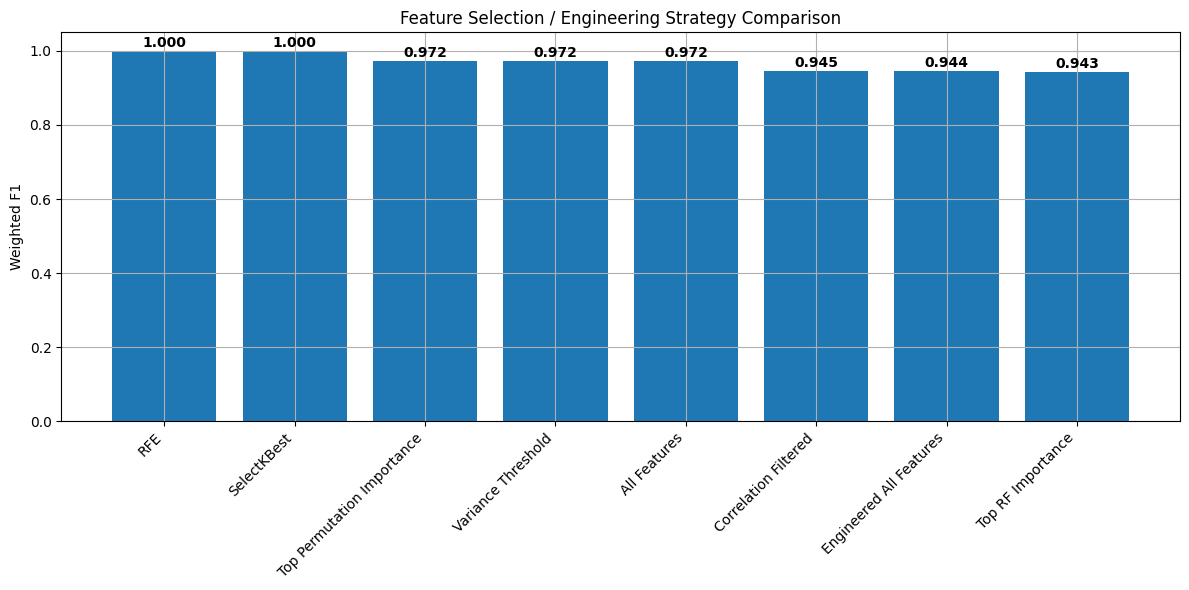

In [14]:
# 14. Compare candidate feature strategies

candidate_feature_sets = {
    "All Features": list(X_train.columns),
    "Variance Threshold": var_selected_features,
    "SelectKBest": kbest_features,
    "RFE": rfe_features,
    "Top RF Importance": top_rf_features,
    "Top Permutation Importance": top_perm_features,
    "Correlation Filtered": corr_filtered_features,
    "Engineered All Features": list(X_train_eng.columns),
}

comparison_rows = []

for method_name, feature_list in candidate_feature_sets.items():
    model = GradientBoostingClassifier(random_state=42)

    if method_name == "Engineered All Features":
        X_train_subset = X_train_eng[feature_list]
        X_valid_subset = X_valid_eng[feature_list]
    else:
        X_train_subset = X_train[feature_list]
        X_valid_subset = X_valid[feature_list]

    score = evaluate_feature_subset(
        model,
        X_train_subset,
        y_train,
        X_valid_subset,
        y_valid
    )

    comparison_rows.append({
        "method": method_name,
        "n_features": len(feature_list),
        "weighted_f1": score
    })

comparison_df = summarize_eval(comparison_rows)

print("\nComparison of feature strategies:")
print(comparison_df)

plt.figure(figsize=(12, 6))
bars = plt.bar(comparison_df["method"], comparison_df["weighted_f1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Weighted F1")
plt.title("Feature Selection / Engineering Strategy Comparison")

for bar, val in zip(bars, comparison_df["weighted_f1"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [15]:
# 15. Cross-validation on best strategy

best_method = comparison_df.iloc[0]["method"]
best_features = candidate_feature_sets[best_method]

print("\nBest method based on validation:", best_method)

if best_method == "Engineered All Features":
    X_cv = pd.concat([X_train_eng, X_valid_eng], axis=0).reset_index(drop=True)[best_features]
else:
    X_cv = pd.concat([X_train, X_valid], axis=0).reset_index(drop=True)[best_features]

y_cv = pd.concat([y_train, y_valid], axis=0).reset_index(drop=True)

cv_model = GradientBoostingClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    cv_model,
    X_cv,
    y_cv,
    scoring="f1_weighted",
    cv=cv
)

print("\nCross-validation weighted F1 scores:", np.round(cv_scores, 4))
print("Mean CV weighted F1:", round(cv_scores.mean(), 4))


Best method based on validation: RFE

Cross-validation weighted F1 scores: [0.8952 0.9658 0.9639 0.928  0.8929]
Mean CV weighted F1: 0.9291



Final selected method: RFE
Number of features used: 11
Final weighted F1 on test set: 0.9443

Final test classification report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.93      0.93      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



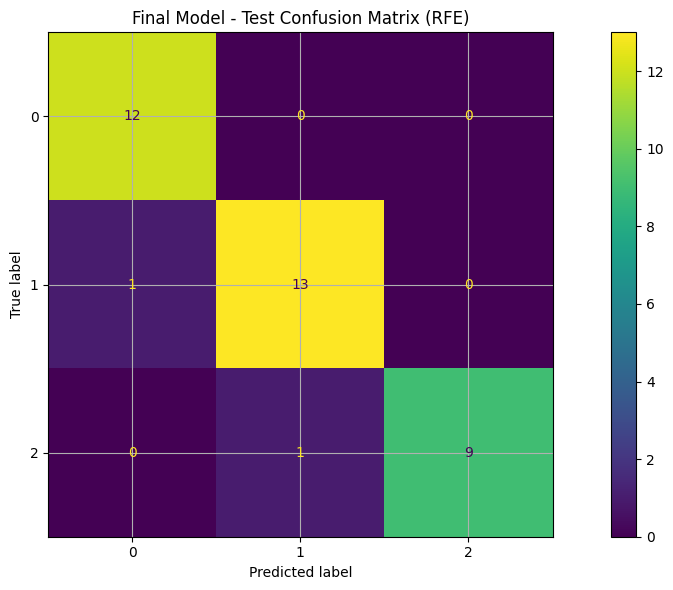

In [16]:
# 16. Final training on train + validation, evaluation on test

if best_method == "Engineered All Features":
    X_final_train = pd.concat([X_train_eng, X_valid_eng], axis=0).reset_index(drop=True)[best_features]
    X_final_test = X_test_eng[best_features]
else:
    X_final_train = pd.concat([X_train, X_valid], axis=0).reset_index(drop=True)[best_features]
    X_final_test = X_test[best_features]

y_final_train = pd.concat([y_train, y_valid], axis=0).reset_index(drop=True)

final_model = GradientBoostingClassifier(random_state=42)
final_model.fit(X_final_train, y_final_train)

test_preds = final_model.predict(X_final_test)
test_f1 = f1_score(y_test, test_preds, average="weighted")

print("\nFinal selected method:", best_method)
print("Number of features used:", len(best_features))
print("Final weighted F1 on test set:", round(test_f1, 4))

print("\nFinal test classification report:")
print(classification_report(y_test, test_preds))

ConfusionMatrixDisplay.from_predictions(y_test, test_preds)
plt.title(f"Final Model - Test Confusion Matrix ({best_method})")
plt.tight_layout()
plt.show()

In [17]:
# 17. Final selected features table

final_features_df = pd.DataFrame({
    "selected_feature": best_features
})

print("\nFinal selected features:")
print(final_features_df)


Final selected features:
                selected_feature
0                        alcohol
1                     malic_acid
2              alcalinity_of_ash
3                      magnesium
4                  total_phenols
5                     flavanoids
6                proanthocyanins
7                color_intensity
8                            hue
9   od280/od315_of_diluted_wines
10                       proline


In [18]:
# 18. Summary table

summary_table = comparison_df.copy()
summary_table["weighted_f1"] = summary_table["weighted_f1"].round(4)

print("\nSummary of all feature strategies:")
print(summary_table)


Summary of all feature strategies:
                       method  n_features  weighted_f1
1                         RFE          11       1.0000
2                 SelectKBest          11       1.0000
3  Top Permutation Importance           5       0.9723
4          Variance Threshold          13       0.9721
5                All Features          13       0.9721
6        Correlation Filtered          12       0.9450
7     Engineered All Features          17       0.9444
8           Top RF Importance           5       0.9432
